# Анализ рынка общественного питания Москвы

**Автор:** Екатерина Шрейс  
**Дата:** 17 февраля 2025 года

## Цель исследования

Провести исследовательский анализ рынка общественного питания Москвы, определить его структуру, географические и ценовые особенности, оценить уровень конкуренции и сформулировать рекомендации для запуска нового заведения.

## Данные

В проекте используются два набора данных.

### `rest_info.csv`

Содержит основную информацию о заведениях:

- **`id`** — идентификатор заведения;
- **`name`** — название;
- **`address`** — адрес;
- **`district`** — административный округ Москвы;
- **`category`** — категория заведения;
- **`hours`** — режим работы;
- **`rating`** — пользовательский рейтинг в Яндекс Картах по шкале от 1 до 5;
- **`chain`** — признак сетевого заведения: `0` — несетевое, `1` — сетевое;
- **`seats`** — количество посадочных мест.

### `rest_price.csv`

Содержит информацию о ценовом сегменте:

- **`id`** — идентификатор заведения;
- **`price`** — ценовая категория;
- **`avg_bill`** — текстовое описание среднего чека или стоимости отдельной позиции;
- **`middle_avg_bill`** — расчётная оценка среднего чека;
- **`middle_coffee_cup`** — расчётная оценка стоимости чашки капучино.

## 1. Загрузка и первичный обзор данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загрузка исходных данных
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [3]:
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


### Первичный обзор `rest_info`

Набор данных содержит 8 406 строк и 9 столбцов. Типы данных соответствуют характеру признаков: числовые показатели хранятся в форматах `int64` и `float64`, текстовые — в `object`.

Пропуски обнаружены в столбцах `hours` и `seats`. Остальные поля на этапе первичного просмотра соответствуют описанию данных. Из-за наличия пропусков количество посадочных мест хранится в формате `float64`.

In [5]:
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


### Первичный обзор `rest_price`

Набор данных содержит 4 058 строк и 5 столбцов. Все поля, кроме `id`, содержат пропуски. Наименьшая заполненность наблюдается у признака `middle_coffee_cup`, поэтому его аналитическая ценность ограничена.

### Объединение наборов данных

Перед объединением проверяется уникальность идентификаторов и соответствие ключей между таблицами.

In [7]:
# Проверка уникальности ключей
info_id = rest_info['id'].nunique()
print(info_id)

price_id = rest_price['id'].nunique()
print(price_id)

# Все идентификаторы из таблицы цен присутствуют в основной таблице
set(rest_price['id']).issubset(set(rest_info['id']))

8406
4058


True

In [8]:
df = rest_info.merge(rest_price, on='id', how='left')

In [9]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


Таблицы объединены по полю `id` с сохранением всех заведений из `rest_info`. Ценовые показатели добавлены для записей, имеющих соответствие в `rest_price`.

## 2. Предобработка данных

На этапе предобработки проверены типы данных, пропуски, текстовые признаки и дубликаты. Для последующего анализа также создан признак круглосуточной работы.

In [10]:
df.head(5)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [11]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

In [12]:
# Оптимизация числовых типов
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')
for column in ['rating', 'middle_avg_bill', 'middle_coffee_cup', 'seats']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [13]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                float32
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

### Анализ пропусков

In [14]:
# Количество пропусков
df.isna().sum().sort_values(ascending=False)

middle_coffee_cup    7871
middle_avg_bill      5257
price                5091
avg_bill             4590
seats                3611
hours                 536
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
dtype: int64

Основные идентификационные и категориальные признаки — название, категория, адрес, округ, рейтинг и сетевая принадлежность — заполнены полностью. Это позволяет использовать весь набор данных для анализа структуры рынка.

In [15]:
# Доля пропусков в неполных столбцах
(df[['middle_coffee_cup',
     'middle_avg_bill',
     'price',
     'avg_bill',
     'seats',
     'hours']]
 .isna()
 .mean() * 100
).round(2).sort_values(ascending=False)

middle_coffee_cup    93.64
middle_avg_bill      62.54
price                60.56
avg_bill             54.60
seats                42.96
hours                 6.38
dtype: float64

In [16]:
def show_missing_stats(data):
    """Возвращает количество и долю пропусков по неполным столбцам."""
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': data.isnull().sum(),
        'Доля пропусков': data.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]

    if missing_stats.empty:
        return "Пропусков в данных нет"

    return (
        missing_stats.style
        .format({'Доля пропусков': '{:.4f}'})
        .background_gradient(cmap='coolwarm')
    )

show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


Наибольшая доля пропусков приходится на `middle_coffee_cup` — около 94%. В `middle_avg_bill`, `price` и `avg_bill` отсутствует более половины значений, а в `seats` — около 43%. В `hours` пропущено около 6% данных.

Заполнять эти значения искусственно нецелесообразно: универсальная замена могла бы исказить распределения цен и вместимости. Пропуски сохранены, а расчёты по отдельным показателям далее выполняются только по доступным наблюдениям. Признак `middle_coffee_cup` в дальнейшем анализе не используется из-за низкой заполненности.

In [18]:
unique_values = df['category'].unique()
unique_values

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

Значения категорий заведений представлены единообразно и не требуют дополнительной обработки.

In [19]:
unique_values = df['district'].unique()
unique_values

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

Названия административных округов представлены единообразно и не требуют дополнительной обработки.

В названиях заведений встречаются различия в регистре, поэтому текстовые поля необходимо нормализовать перед проверкой неявных дубликатов.

Адреса также приводятся к единому регистру и формату для корректного сопоставления записей.

In [23]:
# Нормализация текстовых полей
df[['name', 'address']] = df[['name', 'address']].apply(lambda x: x.str.lower())
df['address'] = df['address'].str.replace(' ', '_')

После нормализации количество уникальных названий уменьшилось на 102. Это указывает на наличие вариантов написания, отличавшихся регистром.

In [25]:
# Количество уникальных названий сетевых заведений
df[df['chain'] == 1]['name'].nunique()

747

In [26]:
# Количество уникальных адресов
df['address'].nunique()

5752

Количество уникальных адресов меньше количества строк в таблице: по одному адресу могут находиться несколько заведений, например в торговых и бизнес-центрах.

### Проверка дубликатов

In [28]:
# Полные дубликаты
print(df.duplicated().sum())

0


Полные дубликаты и повторяющиеся идентификаторы не обнаружены. Дополнительно проверены совпадения по сочетанию нормализованных названия и адреса.

In [30]:
# Повторяющиеся идентификаторы
print(df['id'].duplicated().sum())

0


In [31]:
# Потенциальные дубликаты по названию и адресу
duplicates = df[df.duplicated(subset=['name', 'address'], keep=False)]
duplicates_sorted = duplicates.sort_values(['name', 'address'])

print(f"Найдено потенциальных дубликатов: {len(duplicates)}")
print(f"Уникальных групп дубликатов: {duplicates.groupby(['name', 'address']).ngroups}")
print("\nПримеры дубликатов:")
print(duplicates_sorted[['name', 'address', 'category']].head(10))

Найдено потенциальных дубликатов: 8
Уникальных групп дубликатов: 4

Примеры дубликатов:
                           name                                  address  \
1430                  more poke  москва,_волоколамское_шоссе,_11,_стр._2   
1511                  more poke  москва,_волоколамское_шоссе,_11,_стр._2   
189                        кафе             москва,_парк_ангарские_пруды   
215                        кафе             москва,_парк_ангарские_пруды   
2211  раковарня клешни и хвосты               москва,_проспект_мира,_118   
2420  раковарня клешни и хвосты               москва,_проспект_мира,_118   
3091            хлеб да выпечка              москва,_ярцевская_улица,_19   
3109            хлеб да выпечка              москва,_ярцевская_улица,_19   

      category  
1430  ресторан  
1511  ресторан  
189       кафе  
215       кафе  
2211  ресторан  
2420   бар,паб  
3091  булочная  
3109      кафе  


In [32]:
df = df.drop_duplicates(subset=['name', 'address'], keep='first')

In [33]:
df.head(5)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва,_улица_дыбенко,_7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва,_улица_дыбенко,_36,_корп._1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва,_клязьминская_улица,_15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва,_улица_маршала_федоренко,_12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва,_правобережная_улица,_1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


### Признак круглосуточной работы

In [34]:
# Бинарный признак круглосуточной работы
df = df.copy()
df['is_24/7'] = (df['hours'] == 'ежедневно, круглосуточно').astype('int8')
df['is_24/7'].value_counts().sort_index()

0    7672
1     730
Name: is_24/7, dtype: int64

### Результаты предобработки

Названия и адреса приведены к единому формату. Записи, совпадающие по названию и адресу, удалены как неявные дубликаты. Для круглосуточных заведений создан бинарный признак `is_24/7`.

Полностью заполнены поля `id`, `name`, `category`, `address`, `district`, `rating` и `chain`. Пропуски в ценовых показателях, количестве посадочных мест и режиме работы сохранены и учитываются локально в соответствующих разделах анализа.

## 3. Исследовательский анализ данных

In [36]:
# Описательная статистика числовых признаков
df.describe()

,rating,chain,seats,middle_avg_bill,middle_coffee_cup,is_24/7
count,8402.000000,8402.000000,4792.000000,3149.000000,535.000000,8402.000000
mean,4.230031,0.381219,108.361435,958.053650,174.721497,0.086884
std,0.470318,0.485715,122.841225,1009.734436,88.951088,0.281682
min,1.000000,0.000000,0.000000,0.000000,60.000000,0.000000
25%,4.100000,0.000000,40.000000,375.000000,124.500000,0.000000
50%,4.300000,0.000000,75.000000,750.000000,169.000000,0.000000
75%,4.400000,1.000000,140.000000,1250.000000,225.000000,0.000000
max,5.000000,1.000000,1288.000000,35000.000000,1568.000000,1.000000


Среднее значение `middle_avg_bill` заметно выше медианы, а максимум достигает 35 000 рублей. Распределение имеет выраженный правый хвост, поэтому для описания типичного уровня цен далее используется медиана.

### 3.1. Структура рынка по категориям

In [37]:
category_counts = df['category'].value_counts()
category_counts

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

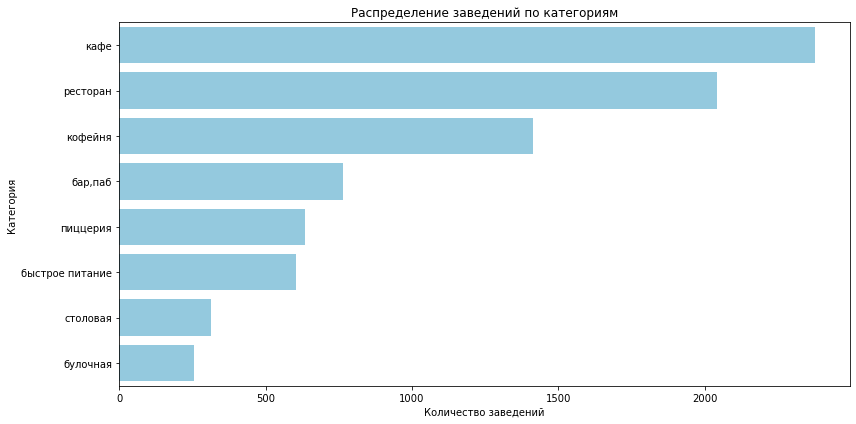

In [38]:
# сортируем по количеству заведений
category_sorted = category_counts.sort_values(ascending=False)

plt.figure(figsize=(12, 6))


ax = sns.barplot(
    x=category_sorted.values,
    y=category_sorted.index,
    color = 'skyblue'
)

plt.title('Распределение заведений по категориям')
plt.xlabel('Количество заведений')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

In [39]:
df['category'].value_counts(normalize=True) * 100

кафе               28.278981
ресторан           24.303737
кофейня            16.817424
бар,паб             9.093073
пиццерия            7.533920
быстрое питание     7.176863
столовая            3.749107
булочная            3.046894
Name: category, dtype: float64

Кафе и рестораны формируют более половины рынка: их доли составляют примерно 28% и 24% соответственно. Кофейни занимают около 17%, а на бары, пиццерии и заведения быстрого питания приходится по 7–9%.

Высокая доля категории указывает на насыщенность сегмента, но сама по себе не позволяет сделать вывод о его инвестиционной привлекательности. Для оценки перспектив необходимо учитывать спрос, локацию, ценовой сегмент и присутствие сетевых игроков.

### 3.2. География заведений

In [40]:
df['district'].value_counts()

Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

In [41]:
district_share = df['district'].value_counts(normalize=True) * 100
district_sorted = district_share.sort_values(ascending=False)

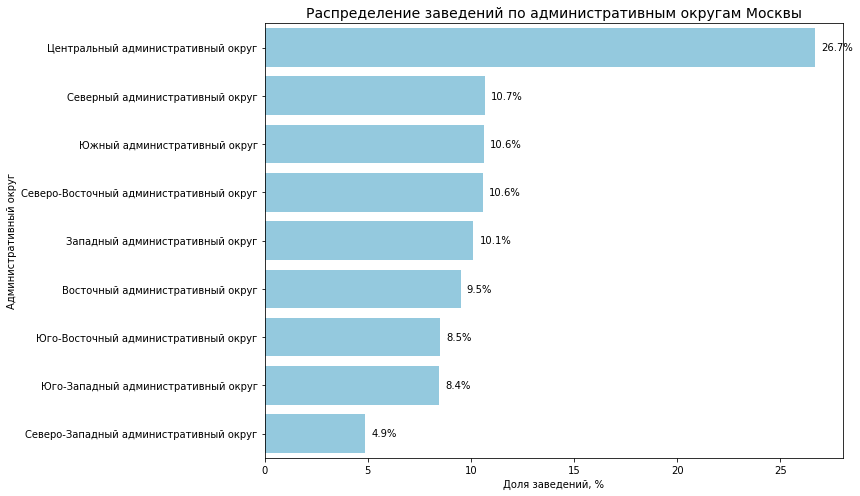

In [42]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=district_sorted.values,
    y=district_sorted.index,
    orient='h',
    color = 'skyblue'
)

plt.title('Распределение заведений по административным округам Москвы', fontsize=14)
plt.xlabel('Доля заведений, %')
plt.ylabel('Административный округ')

# Добавим подписи процентов
for i, v in enumerate(district_sorted.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()

На Центральный административный округ приходится около 26% заведений — это наиболее насыщенная территория. В большинстве остальных округов сосредоточено по 8–10% объектов, а минимальная доля наблюдается в Северо-Западном округе — около 4%.

Низкая концентрация может означать как меньшую конкуренцию, так и более ограниченный спрос, поэтому этот показатель следует интерпретировать вместе с данными о населении, трафике и покупательной способности.

In [43]:
cao_categories = df[df['district'] == 'Центральный административный округ']['category'].value_counts()
cao_categories

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

In [44]:
cao_categories_pct = df[df['district'] == 'Центральный административный округ']['category'].value_counts(normalize=True) * 100
cao_categories_pct

ресторан           29.884032
кафе               20.695807
кофейня            19.090098
бар,паб            16.235504
пиццерия            5.040143
быстрое питание     3.880464
столовая            2.943800
булочная            2.230152
Name: category, dtype: float64

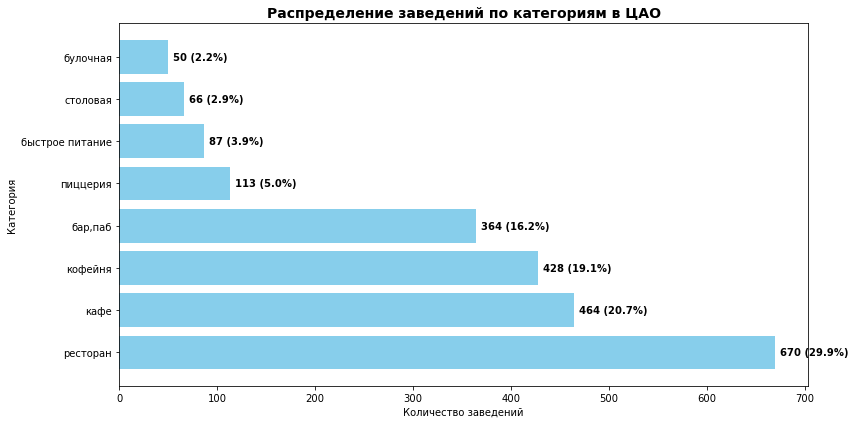

In [45]:
plt.figure(figsize=(12, 6))

# Горизонтальные столбцы
bars = plt.barh(cao_categories.index, cao_categories.values, color='skyblue')

# Добавляем значения и проценты
for i, (cat, count) in enumerate(cao_categories.items()):
    pct = cao_categories_pct[cat]
    plt.text(count + 5, i, f'{count} ({pct:.1f}%)', va='center', fontweight='bold')

plt.xlabel('Количество заведений')
plt.ylabel('Категория')
plt.title('Распределение заведений по категориям в ЦАО', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

В данных представлены девять административных округов Москвы. В ЦАО преобладают рестораны — около 30% заведений округа. Кафе, кофейни и бары формируют ещё значительную часть рынка, тогда как пиццерии, быстрое питание, столовые и булочные представлены заметно слабее.

Таким образом, центральный рынок ориентирован прежде всего на ресторанные и досуговые форматы и характеризуется высокой плотностью конкурентов.

### 3.3. Сетевые и несетевые заведения

In [46]:
chain_total = df['chain'].value_counts()
chain_total_pct = df['chain'].value_counts(normalize=True) * 100

print("Общее соотношение сетевых заведений к несетевым:")
print(f"Несетевые (0): {chain_total[0]} заведений ({chain_total_pct[0]:.1f}%)")
print(f"Сетевые (1): {chain_total[1]} заведений ({chain_total_pct[1]:.1f}%)")

Общее соотношение сетевых заведений к несетевым:
Несетевые (0): 5199 заведений (61.9%)
Сетевые (1): 3203 заведений (38.1%)


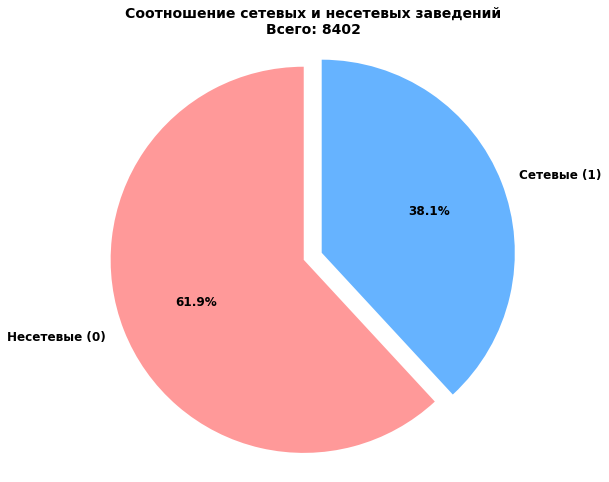

In [47]:
plt.figure(figsize=(8, 8))
plt.pie([chain_total[0], chain_total[1]], 
        labels=['Несетевые (0)', 'Сетевые (1)'],
        autopct='%1.1f%%', 
        colors=['#ff9999', '#66b3ff'], 
        startangle=90, 
        explode=(0.05, 0.05),
        textprops={'fontweight': 'bold', 'fontsize': 12})
plt.title(f'Соотношение сетевых и несетевых заведений\nВсего: {len(df)}', 
          fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

Несетевые заведения преобладают и составляют около 62% рынка. На сетевые приходится примерно 38%.

In [48]:
# Соотношение сетевых и несетевых заведений по категориям
chain_by_cat = pd.crosstab(df['category'], df['chain'])
chain_by_cat.columns = ['Несетевые', 'Сетевые']
chain_by_cat['Доля_сетевых'] = (
    chain_by_cat['Сетевые'] /
    (chain_by_cat['Несетевые'] + chain_by_cat['Сетевые']) * 100
).round(1)
chain_by_cat = chain_by_cat.sort_values('Доля_сетевых', ascending=False)

print(chain_by_cat)

                 Несетевые  Сетевые  Доля_сетевых
category                                         
булочная                99      157          61.3
пиццерия               303      330          52.1
кофейня                693      720          51.0
быстрое питание        371      232          38.5
ресторан              1313      729          35.7
кафе                  1597      779          32.8
столовая               227       88          27.9
бар,паб                596      168          22.0


Чаще всего сетевой формат встречается среди булочных, пиццерий и кофеен: доля сетей в этих категориях превышает 50%. Реже всего сетевыми являются бары и пабы — менее четверти заведений.

In [49]:
chain_share = (df.groupby('category')['chain']
               .mean()
               .sort_values(ascending=True) * 100)

chain_df = chain_share.reset_index()
chain_df.columns = ['category', 'chain_share']

In [50]:
def entry_level(x):
    if x > 50:
        return 'Высокий'
    elif x >= 30:
        return 'Средний'
    else:
        return 'Низкий'

chain_df['entry_level'] = chain_df['chain_share'].apply(entry_level)

In [51]:
palette = {
    'Высокий': '#d62728',   # красный
    'Средний': '#ff7f0e',   # оранжевый
    'Низкий': '#2ca02c'     # зелёный
}

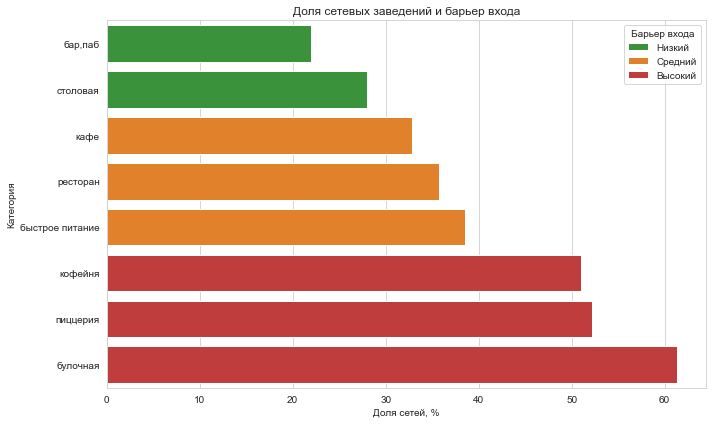

In [52]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.barplot(
    data=chain_df,
    x='chain_share',
    y='category',
    hue='entry_level',
    dodge=False,
    palette=palette
)

plt.title('Доля сетевых заведений и барьер входа')
plt.xlabel('Доля сетей, %')
plt.ylabel('Категория')
plt.legend(title='Барьер входа')

plt.tight_layout()
plt.show()

Наиболее высокая концентрация сетей наблюдается в сегментах, хорошо поддающихся стандартизации: булочных, пиццериях и кофейнях. Для нового независимого проекта вход в эти категории может потребовать более сильного бренда и чёткой дифференциации.

Бары, кафе, рестораны и столовые остаются более фрагментированными, поэтому локальная концепция в этих сегментах потенциально имеет больше пространства для конкуренции.

### 3.4. Количество посадочных мест

In [53]:
df[['seats']].describe().round(1)

,seats
count,4792.0
mean,108.4
std,122.8
min,0.0
25%,40.0
50%,75.0
75%,140.0
max,1288.0


Среднее количество посадочных мест заметно превышает медиану, что указывает на правостороннюю асимметрию и наличие крупных заведений. Максимальное значение существенно отличается от основной массы наблюдений, поэтому типичный размер заведения корректнее оценивать по медиане.

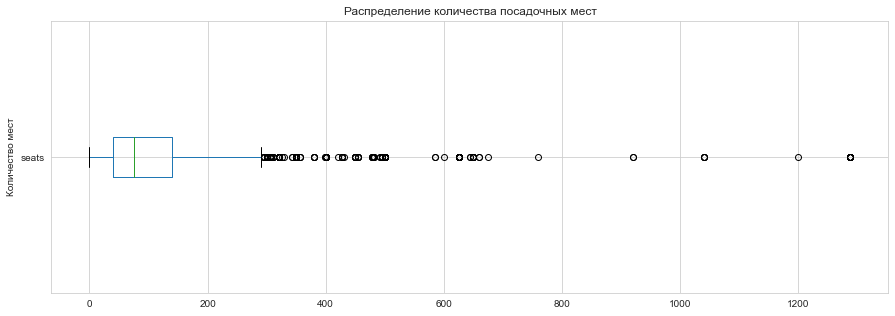

In [54]:
# Распределение и выбросы
boxplot = df.boxplot(column='seats', vert=False, figsize=(15, 5))
plt.title('Распределение количества посадочных мест')
plt.ylabel('Количество мест')
plt.show()

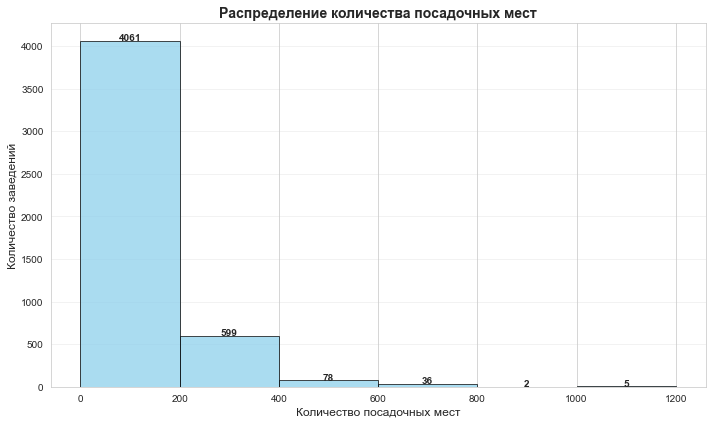

Распределение заведений по количеству мест:
--------------------------------------------------
0-200 мест: 4061 заведений (48.3%)
200-400 мест: 599 заведений (7.1%)
400-600 мест: 78 заведений (0.9%)
600-800 мест: 36 заведений (0.4%)
800-1000 мест: 2 заведений (0.0%)
1000-1200 мест: 4 заведений (0.0%)


In [55]:
# Строим гистограмму
bins = [0, 200, 400, 600, 800, 1000, 1200]
plt.figure(figsize=(10, 6))

# Строим гистограмму
plt.hist(df['seats'].dropna(), bins=bins, color='skyblue', 
         edgecolor='black', alpha=0.7)

plt.xlabel('Количество посадочных мест', fontsize=12)
plt.ylabel('Количество заведений', fontsize=12)
plt.title('Распределение количества посадочных мест', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения над столбцами
n, bins, patches = plt.hist(df['seats'].dropna(), bins=bins, alpha=0)
for i, patch in enumerate(patches):
    height = patch.get_height()
    if height > 0:
        plt.text(patch.get_x() + patch.get_width()/2., height + 5,
                f'{int(height)}', ha='center', fontweight='bold')

plt.xticks(bins)
plt.tight_layout()
plt.show()

# Статистика по интервалам
print("Распределение заведений по количеству мест:")
print("-" * 50)
for i in range(len(bins)-1):
    count = len(df[(df['seats'] >= bins[i]) & (df['seats'] < bins[i+1])])
    print(f"{bins[i]}-{bins[i+1]} мест: {count} заведений ({count/len(df)*100:.1f}%)")

Большинство заведений рассчитано не более чем на 200–250 посадочных мест. Значения от 400 до 1 200 мест образуют длинный правый хвост и, вероятно, относятся к крупным банкетным залам, столовым при организациях или многофункциональным ресторанным площадкам.

In [57]:
# Среднее и медианное количество мест по категориям
pivot_seats = pd.pivot_table(
    df,
    values='seats',
    index='category',
    aggfunc=['mean', 'median']
).round(0)

print("Среднее количество мест по категориям:")
print(pivot_seats)

Среднее количество мест по категориям:
                  mean median
                 seats  seats
category                     
бар,паб          124.0   82.0
булочная          89.0   50.0
быстрое питание   99.0   65.0
кафе              97.0   60.0
кофейня          111.0   80.0
пиццерия          94.0   55.0
ресторан         122.0   86.0
столовая         100.0   76.0


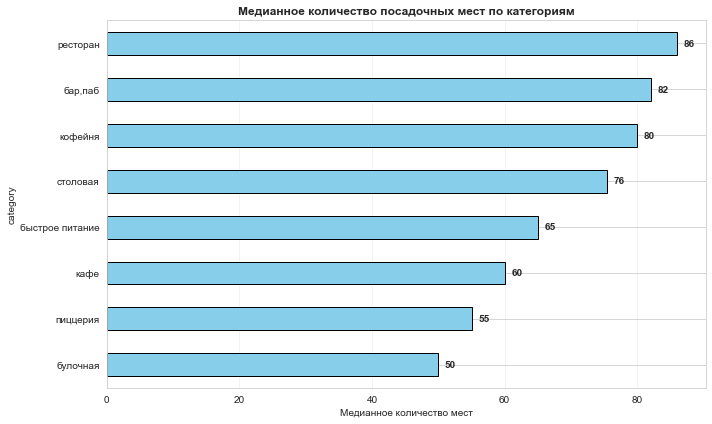

In [58]:
# Среднее количество мест по категориям
median_seats = df.groupby('category')['seats'].median().sort_values()

plt.figure(figsize=(10, 6))
median_seats.plot(kind='barh', color='skyblue', edgecolor='black')
plt.xlabel('Медианное количество мест')
plt.title('Медианное количество посадочных мест по категориям', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Добавляем значения
for i, v in enumerate(median_seats):
    plt.text(v + 1, i, f'{v:.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Медианное количество посадочных мест различается по категориям. Наиболее вместительными являются рестораны — около 86 мест, наиболее компактными — булочные, около 50 мест. Использование медианы снижает влияние единичных крупных объектов.

### 3.5. Рейтинги заведений

In [59]:
df['rating'].describe()

count    8402.000000
mean        4.230031
std         0.470318
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [60]:
df.groupby('category')['rating'].mean().sort_values(ascending=False)

category
бар,паб            4.387696
пиццерия           4.301264
ресторан           4.290401
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.124285
быстрое питание    4.050249
Name: rating, dtype: float32

In [61]:
df.groupby('category')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",764.0,4.387691,0.380392,1.1,4.3,4.4,4.6,5.0
булочная,256.0,4.268362,0.386303,1.3,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050251,0.560949,1.1,3.9,4.2,4.3,5.0
кафе,2376.0,4.124280,0.566003,1.0,4.0,4.2,4.4,5.0
кофейня,1413.0,4.277278,0.372251,1.4,4.1,4.3,4.4,5.0
пиццерия,633.0,4.301267,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2042.0,4.290394,0.413142,1.0,4.2,4.3,4.5,5.0
столовая,315.0,4.211428,0.454205,1.0,4.1,4.3,4.4,5.0


In [62]:
rating_mean = (
    df.groupby('category')['rating']
      .mean()
      .sort_values()
)

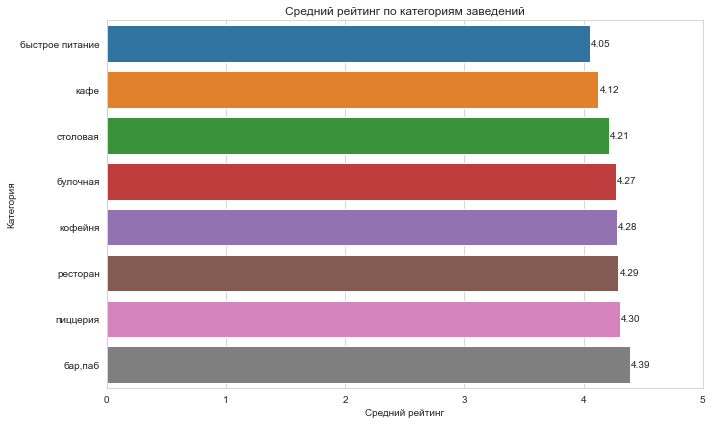

In [63]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.barplot(
    x=rating_mean.values,
    y=rating_mean.index,
    orient='h'
)

plt.title('Средний рейтинг по категориям заведений')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')

# Добавим подписи
for i, v in enumerate(rating_mean.values):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center')

plt.xlim(0, 5)  # можно убрать, если диапазон другой
plt.tight_layout()
plt.show()

Средние рейтинги категорий находятся в узком диапазоне. Максимальное медианное значение наблюдается у баров и пабов, минимальное — у заведений быстрого питания, однако различия невелики.

Это означает, что высокий пользовательский рейтинг является скорее базовым требованием рынка, чем самостоятельным конкурентным преимуществом.

### 3.6. Факторы, связанные с рейтингом

In [66]:
import phik

columns_for_corr = [
    'rating', 'category', 'district', 'chain',
    'seats', 'price', 'is_24/7'
]
df_corr = df[columns_for_corr].copy()
phi_matrix = df_corr.phik_matrix()

print("МАТРИЦА КОРРЕЛЯЦИИ PHI_K:")
print("=" * 50)
print(phi_matrix.round(3))

interval columns not set, guessing: ['rating', 'chain', 'seats', 'is_24/7']
МАТРИЦА КОРРЕЛЯЦИИ PHI_K:
          rating  category  district  chain  seats  price  is_24/7
rating     1.000     0.199     0.189  0.119  0.000  0.262    0.161
category   0.199     1.000     0.175  0.266  0.049  0.567    0.245
district   0.189     0.175     1.000  0.064  0.352  0.203    0.076
chain      0.119     0.266     0.064  1.000  0.057  0.218    0.043
seats      0.000     0.049     0.352  0.057  1.000  0.088    0.043
price      0.262     0.567     0.203  0.218  0.088  1.000    0.084
is_24/7    0.161     0.245     0.076  0.043  0.043  0.084    1.000


Наиболее заметная связь рейтинга обнаружена с ценовой категорией: коэффициент Phi_K составляет около 0,26. Связь остаётся слабой, поэтому её нельзя интерпретировать как сильную зависимость или причинный эффект.

Среди остальных признаков выделяются связи между категорией заведения и ценовым сегментом, а также между количеством посадочных мест и округом.

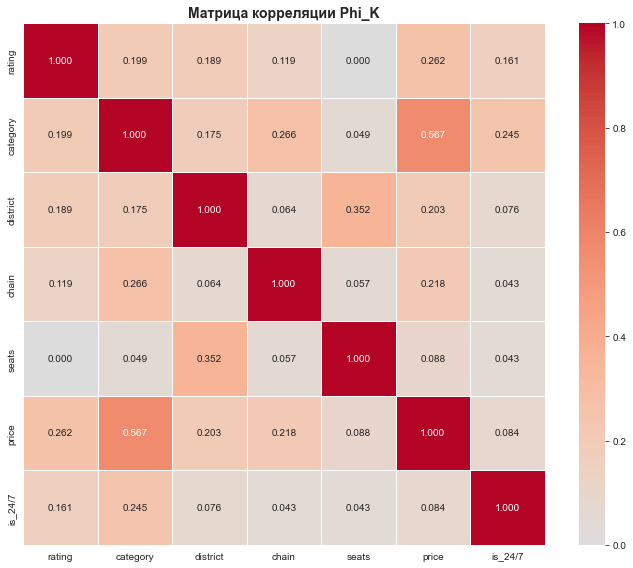

In [68]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    phi_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Матрица корреляции Phi_K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

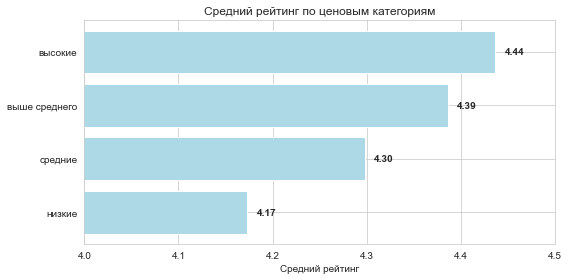

In [69]:
# Проверяем взаимосвязь рейтинга и цены
# Средний рейтинг по ценовым категориям
rating_by_price = df.groupby('price')['rating'].mean().sort_values()

# Горизонтальный график
plt.figure(figsize=(8, 4))
bars = plt.barh(rating_by_price.index, rating_by_price.values, color='lightblue')

# Добавляем значения
for bar, val in zip(bars, rating_by_price.values):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.2f}', va='center', fontweight='bold')

plt.xlabel('Средний рейтинг')
plt.title('Средний рейтинг по ценовым категориям')
plt.xlim(4.0, 4.5)  # фокус на диапазон рейтингов
plt.tight_layout()
plt.show()

Средний рейтинг последовательно увеличивается при переходе к более высоким ценовым категориям. Наблюдаемая тенденция согласуется с результатом корреляционного анализа, но не доказывает, что рост цены сам по себе повышает рейтинг.

### 3.7. Крупнейшие сети Москвы

In [70]:
chains = df[df['chain'] == 1].groupby(['name', 'category'])

In [71]:
top_chains = (
    chains
    .agg(
        count=('id', 'count'),
        rating_mean=('rating', 'mean')
    )
    .sort_values('count', ascending=False)
    .head(15)
    .reset_index()
)

top_chains

,name,category,count,rating_mean
0,шоколадница,кофейня,119,4.178151
1,домино'с пицца,пиццерия,76,4.169737
2,додо пицца,пиццерия,74,4.286487
3,one price coffee,кофейня,71,4.064789
4,яндекс лавка,ресторан,69,3.872464
5,cofix,кофейня,65,4.075385
6,prime,ресторан,49,4.114285
7,кофепорт,кофейня,42,4.147619
8,кулинарная лавка братьев караваевых,кафе,39,4.394872
9,теремок,ресторан,36,4.105556


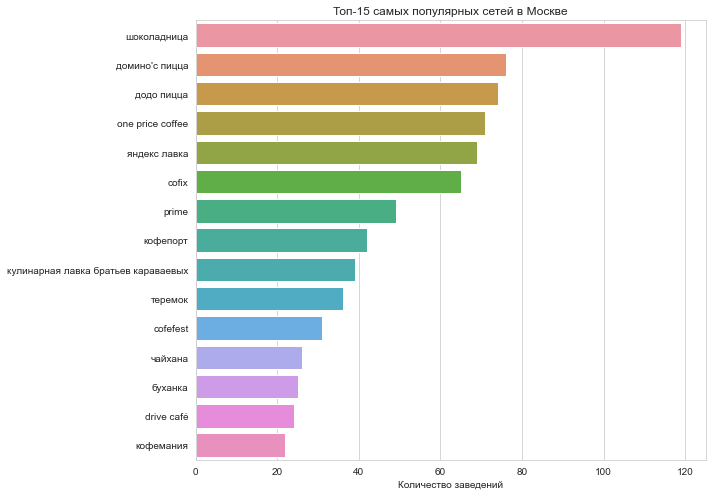

In [73]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_chains['count'],
    y=top_chains['name']
)

plt.title('Топ-15 самых популярных сетей в Москве')
plt.xlabel('Количество заведений')
plt.ylabel('')

plt.tight_layout()
plt.show()

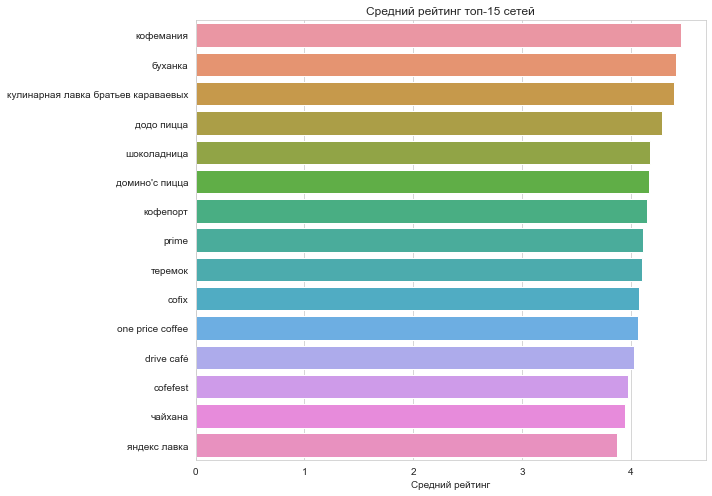

In [74]:
top_chains_sorted = top_chains.sort_values('rating_mean', ascending=False) 
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_chains_sorted['rating_mean'],
    y=top_chains_sorted['name']
)

plt.title('Средний рейтинг топ-15 сетей')
plt.xlabel('Средний рейтинг')
plt.ylabel('')

plt.tight_layout()
plt.show()

В топе по количеству точек преобладают кофейни и пиццерии, что подтверждает высокую степень масштабирования этих сегментов. При этом размер сети не гарантирует более высокий рейтинг: часть сетей с 30–40 точками оценивается пользователями выше крупнейших игроков.

Для нового проекта это указывает на возможность конкурировать не только масштабом, но и качеством локальной концепции, продукта и сервиса.

### 3.8. Средний чек по округам

In [75]:
df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053650
std       1009.734436
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

Среднее значение среднего чека заметно выше медианы, а стандартное отклонение велико. Это подтверждает неоднородность цен и наличие небольшого числа дорогих заведений.

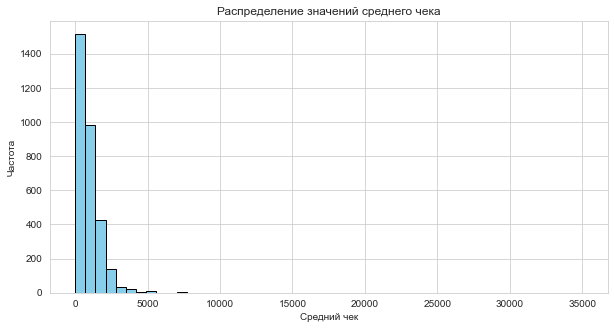

In [76]:
plt.figure(figsize=(10, 5))
plt.hist(
    df['middle_avg_bill'].dropna(),
    bins=50,
    color='skyblue',
    edgecolor='black'
)
plt.title('Распределение значений среднего чека')
plt.ylabel('Частота')
plt.xlabel('Средний чек')
plt.show()

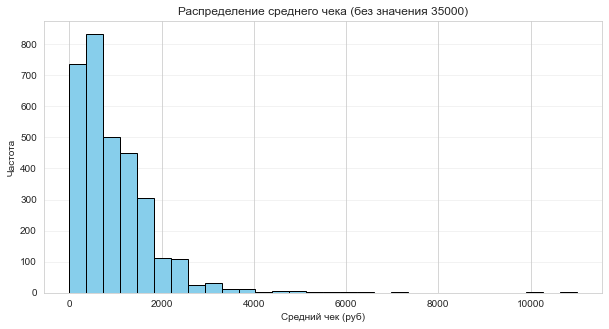

Было значений: 3149
Стало: 3148
Убрано значений с чеком >= 35000: 1


In [77]:
# Распределение без экстремального значения 35 000 рублей
bills_filtered = df['middle_avg_bill'].dropna()
bills_filtered = bills_filtered[bills_filtered < 35000]

plt.figure(figsize=(10, 5))
plt.hist(bills_filtered, bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение среднего чека (без значения 35000)')
plt.xlabel('Средний чек (руб)')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Было значений: {len(df['middle_avg_bill'].dropna())}")
print(f"Стало: {len(bills_filtered)}")
print(f"Убрано значений с чеком >= 35000: {len(df['middle_avg_bill'].dropna()) - len(bills_filtered)}")

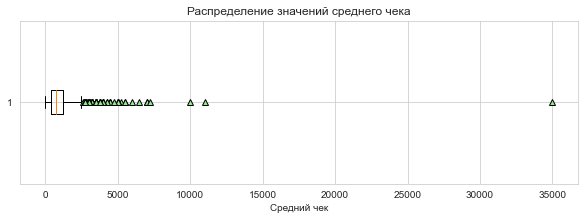

In [78]:
plt.figure(figsize=(10, 3))
plt.boxplot(
    df['middle_avg_bill'].dropna(),
    vert=False,
    flierprops=dict(markerfacecolor='lightgreen', marker='^')
)
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.show()

Основная часть значений среднего чека находится ниже 2 000 рублей. Распределение имеет длинный правый хвост; значение 35 000 рублей и несколько наблюдений выше 10 000 рублей являются аномальными относительно основной выборки.

In [79]:
df.groupby('district')['middle_avg_bill'].describe()

,count,mean,std,min,25%,50%,75%,max
district,,,,,,,,
Восточный административный округ,260.0,820.626953,850.903503,50.0,338.00,575.0,1100.0,10000.0
Западный административный округ,306.0,1053.225464,779.008423,50.0,427.50,1000.0,1500.0,5250.0
Северный административный округ,322.0,927.959656,912.608765,130.0,350.00,650.0,1250.0,11000.0
Северо-Восточный административный округ,301.0,716.611267,591.232117,50.0,325.00,500.0,950.0,4500.0
Северо-Западный административный округ,157.0,822.222900,595.055176,120.0,340.00,700.0,1100.0,2900.0
Центральный административный округ,1060.0,1191.057495,920.015747,0.0,500.00,1000.0,1500.0,7250.0
Юго-Восточный административный округ,194.0,654.097961,566.825684,30.0,281.25,450.0,887.5,3750.0
Юго-Западный административный округ,235.0,792.561707,559.173035,100.0,350.00,600.0,1100.0,2750.0
Южный административный округ,314.0,834.398071,2008.639160,100.0,350.00,500.0,1037.5,35000.0


In [80]:
df_bill = df.dropna(subset=['middle_avg_bill']).copy()
df_bill['district'] = df_bill['district'].astype(str)

In [81]:
district_bill = (df_bill.groupby('district')['middle_avg_bill']
                 .agg(count='count', median='median', mean='mean')
                 .sort_values('median', ascending=False))

district_bill

,count,median,mean
district,,,
Западный административный округ,306,1000.0,1053.225464
Центральный административный округ,1060,1000.0,1191.057495
Северо-Западный административный округ,157,700.0,822.222900
Северный административный округ,322,650.0,927.959656
Юго-Западный административный округ,235,600.0,792.561707
Восточный административный округ,260,575.0,820.626953
Северо-Восточный административный округ,301,500.0,716.611267
Южный административный округ,314,500.0,834.398071
Юго-Восточный административный округ,194,450.0,654.097961


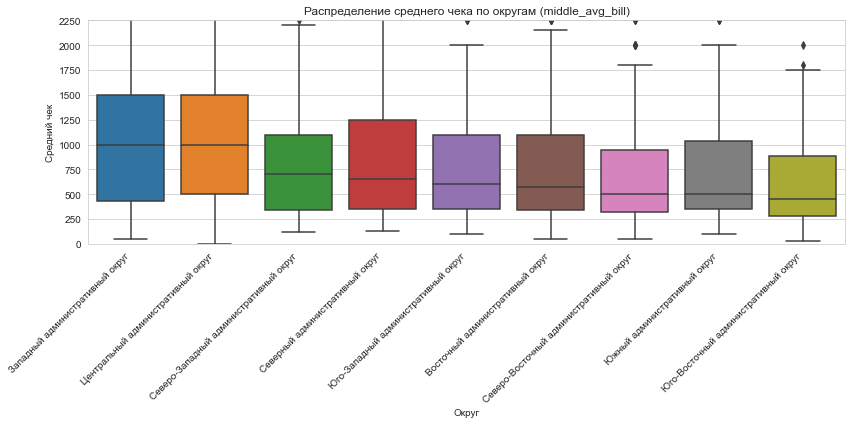

In [82]:
order = district_bill.index

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.boxplot(
    data=df_bill,
    x='district',
    y='middle_avg_bill',
    order=order
)
plt.xticks(rotation=45, ha='right')
plt.title('Распределение среднего чека по округам (middle_avg_bill)')
plt.xlabel('Округ')
plt.ylabel('Средний чек')
plt.ylim(0, df_bill['middle_avg_bill'].quantile(0.95))
plt.tight_layout()
plt.show()

In [83]:
df_bill['is_center'] = (df_bill['district'] == 'Центральный административный округ').astype(int)

center_vs_other = df_bill.groupby('is_center')['middle_avg_bill'].agg(
    count='count', median='median', mean='mean'
)
center_vs_other

,count,median,mean
is_center,,,
0,2089,600.0,839.822876
1,1060,1000.0,1191.057495


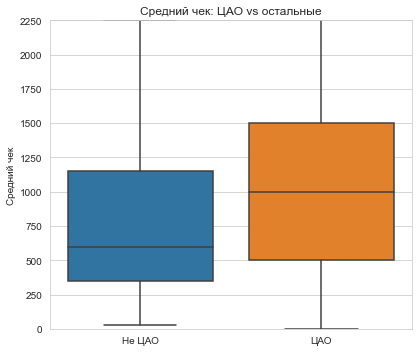

In [84]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df_bill, x='is_center', y='middle_avg_bill')
plt.xticks([0, 1], ['Не ЦАО', 'ЦАО'])
plt.title('Средний чек: ЦАО vs остальные')
plt.xlabel('')
plt.ylabel('Средний чек')
plt.tight_layout()
plt.ylim(0, df_bill['middle_avg_bill'].quantile(0.95))
plt.show()

Медианный средний чек наиболее высок в Центральном и Западном административных округах. В ЦАО он составляет около 1 000 рублей против примерно 600 рублей в остальных округах. Более низкие медианные значения наблюдаются в Юго-Восточном и Северо-Восточном округах.

Результаты указывают на выраженную территориальную дифференциацию цен: центр и западные округа чаще относятся к более дорогому сегменту, а периферийные округа — к более доступному. При этом данные не содержат информации об аренде, доходах населения и пешеходном трафике, поэтому возможные причины различий требуют дополнительной проверки на внешних источниках.

# Итоговый вывод и рекомендации

## Общий обзор

Проведён исследовательский анализ 8 406 заведений общественного питания Москвы. Данные объединены из двух источников и включают сведения о категориях, расположении, сетевой принадлежности, рейтингах, посадочных местах и ценовом сегменте.

В ходе предобработки нормализованы названия и адреса, удалены совпадения по сочетанию названия и адреса, оптимизированы числовые типы и создан признак круглосуточной работы. Пропуски в ценовых показателях и количестве мест не заполнялись искусственно; соответствующие расчёты выполнялись по доступным наблюдениям.

## Ключевые результаты

Кафе и рестораны формируют более половины рынка, а Центральный административный округ концентрирует около 26% всех заведений. Это делает центр наиболее насыщенной и конкурентной территорией.

Несетевые заведения составляют около 62% рынка. Наиболее высокая доля сетевых игроков наблюдается среди булочных, пиццерий и кофеен, где стандартизация и масштабирование особенно распространены.

Средние рейтинги категорий различаются незначительно. Наиболее заметная связь рейтинга обнаружена с ценовой категорией, однако коэффициент Phi_K около 0,26 указывает лишь на слабую зависимость и не позволяет делать причинные выводы.

Средний чек заметно зависит от расположения. В ЦАО медианное значение составляет около 1 000 рублей, тогда как за его пределами — около 600 рублей. Наиболее доступный ценовой уровень наблюдается в ряде периферийных округов.

## Ограничения анализа

Данные о среднем чеке и количестве посадочных мест заполнены не полностью, поэтому результаты по этим показателям относятся только к доступной части выборки. Набор данных также не содержит сведений об арендных ставках, трафике, численности населения, выручке и фактическом спросе. Эти факторы необходимы для полноценной инвестиционной оценки.

## Рекомендации

Для премиального проекта ЦАО предоставляет аудиторию с более высоким средним чеком, но одновременно предполагает максимальную конкуренцию. Выход в центр оправдан при наличии сильной концепции и достаточного бюджета на привлечение клиентов.

Для независимого проекта более сбалансированным вариантом выглядят округа со средней плотностью заведений и умеренным уровнем цен. В таких локациях можно снизить давление конкуренции и сосредоточиться на локальной аудитории.

В сегментах кофеен, пиццерий и булочных высока доля сетей, поэтому новому игроку потребуется заметная дифференциация или потенциал масштабирования. Более фрагментированные категории — бары, отдельные форматы кафе и ресторанов — оставляют больше пространства для локальной концепции.

Перед принятием инвестиционного решения рекомендуется дополнить анализ данными об аренде, пешеходном трафике, населении, конкурентах в радиусе выбранной локации и финансовой модели проекта.